In [16]:
import numpy as nm
import matplotlib.pyplot as mtp
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [17]:
print("Importing the dataset...")

Importing the dataset...


In [18]:

data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}

df = pd.DataFrame(data)

In [19]:
le = LabelEncoder()
df['vehicle_type_encoded'] = nm.asarray(le.fit_transform(df['vehicle_type']), dtype=nm.int64)

x = df[['mileage', 'fuel_efficiency', 'maintenance_cost', 'vehicle_type_encoded']].values

In [20]:
wcss_no_scale = []
for i in range(1, 6):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x)
    wcss_no_scale.append(kmeans.inertia_)

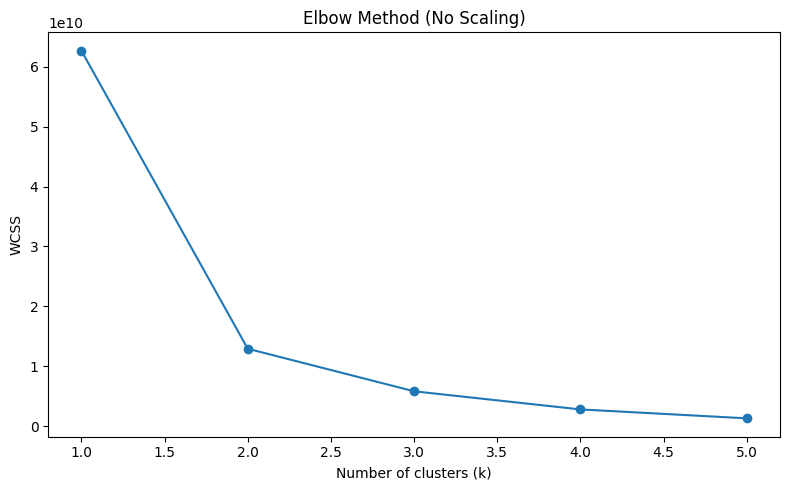

In [21]:
mtp.figure(figsize=(8, 5))
mtp.plot(range(1, 6), wcss_no_scale, marker='o')
mtp.title('Elbow Method (No Scaling)')
mtp.xlabel('Number of clusters (k)')
mtp.ylabel('WCSS')
mtp.tight_layout()
mtp.show()

In [22]:
kmeans_no_scale = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_no_scale = kmeans_no_scale.fit_predict(x)

df['cluster_no_scale'] = y_no_scale

colors = ['blue', 'green', 'red']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3']

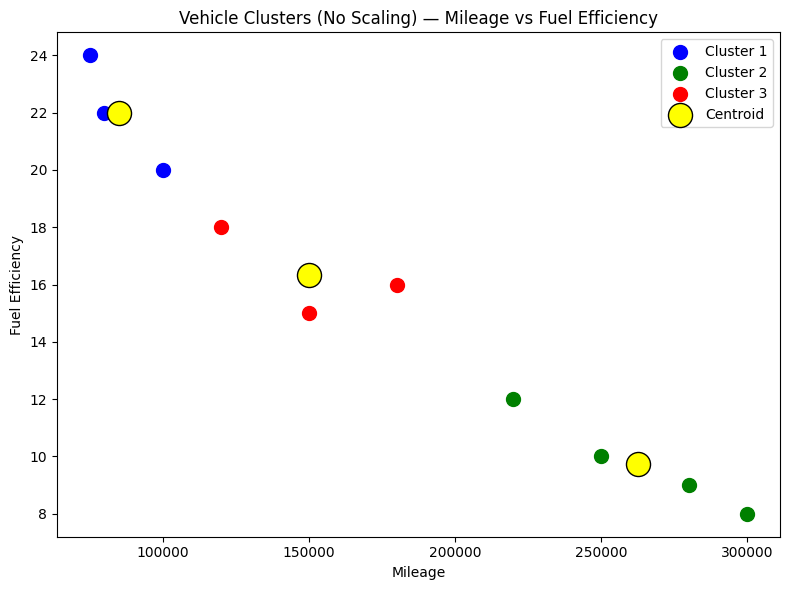

In [23]:
mtp.figure(figsize=(8, 6))
for i in range(3):
    mtp.scatter(
        x[y_no_scale == i, 0],
        x[y_no_scale == i, 1],
        s=100, c=colors[i], label=labels[i]
    )
mtp.scatter(
    kmeans_no_scale.cluster_centers_[:, 0],
    kmeans_no_scale.cluster_centers_[:, 1],
    s=300, c='yellow', label='Centroid', edgecolors='black'
)
mtp.title('Vehicle Clusters (No Scaling) — Mileage vs Fuel Efficiency')
mtp.xlabel('Mileage')
mtp.ylabel('Fuel Efficiency')
mtp.legend()
mtp.tight_layout()
mtp.show()

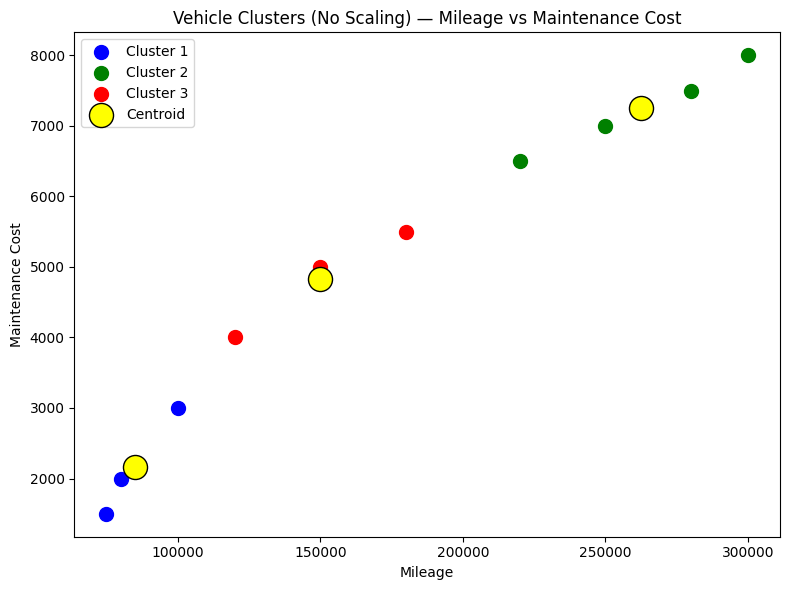

In [24]:
mtp.figure(figsize=(8, 6))
for i in range(3):
    mtp.scatter(
        x[y_no_scale == i, 0],
        x[y_no_scale == i, 2],
        s=100, c=colors[i], label=labels[i]
    )
mtp.scatter(
    kmeans_no_scale.cluster_centers_[:, 0],
    kmeans_no_scale.cluster_centers_[:, 2],
    s=300, c='yellow', label='Centroid', edgecolors='black'
)
mtp.title('Vehicle Clusters (No Scaling) — Mileage vs Maintenance Cost')
mtp.xlabel('Mileage')
mtp.ylabel('Maintenance Cost')
mtp.legend()
mtp.tight_layout()
mtp.show()

In [25]:
x_scaled = x.copy().astype(float)
scaler = StandardScaler()
x_scaled[:, :3] = scaler.fit_transform(x_scaled[:, :3])

wcss_scaled = []
for i in range(1, 6):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x_scaled)
    wcss_scaled.append(kmeans.inertia_)

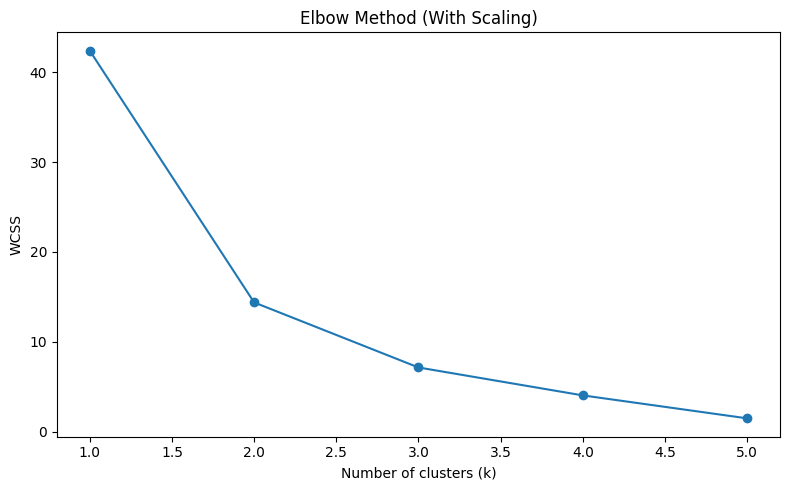

In [26]:
mtp.figure(figsize=(8, 5))
mtp.plot(range(1, 6), wcss_scaled, marker='o')
mtp.title('Elbow Method (With Scaling)')
mtp.xlabel('Number of clusters (k)')
mtp.ylabel('WCSS')
mtp.tight_layout()
mtp.show()

In [27]:
kmeans_scaled = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_scaled = kmeans_scaled.fit_predict(x_scaled)

df['cluster_scaled'] = y_scaled

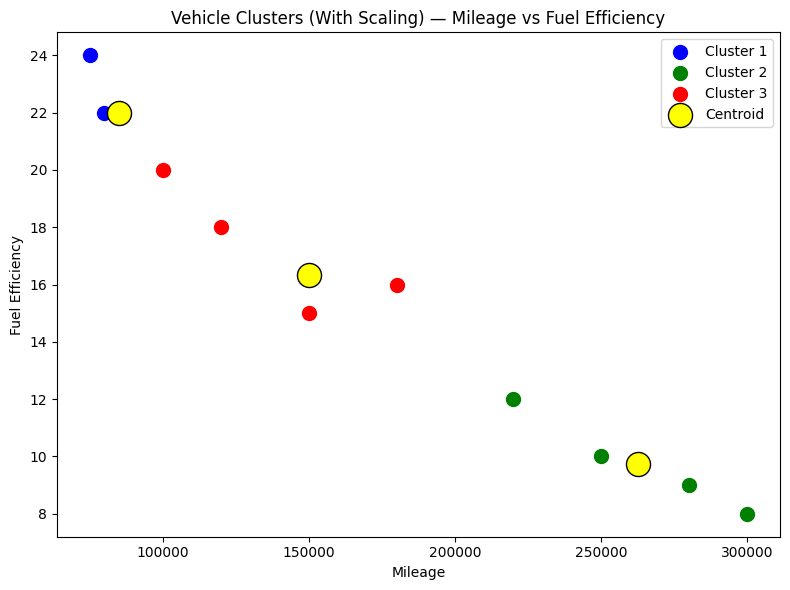

In [28]:
mtp.figure(figsize=(8, 6))
for i in range(3):
    mtp.scatter(
        x[y_scaled == i, 0],
        x[y_scaled == i, 1],
        s=100, c=colors[i], label=labels[i]
    )
mtp.scatter(
    kmeans_no_scale.cluster_centers_[:, 0],
    kmeans_no_scale.cluster_centers_[:, 1],
    s=300, c='yellow', label='Centroid', edgecolors='black'
)
mtp.title('Vehicle Clusters (With Scaling) — Mileage vs Fuel Efficiency')
mtp.xlabel('Mileage')
mtp.ylabel('Fuel Efficiency')
mtp.legend()
mtp.tight_layout()
mtp.show()

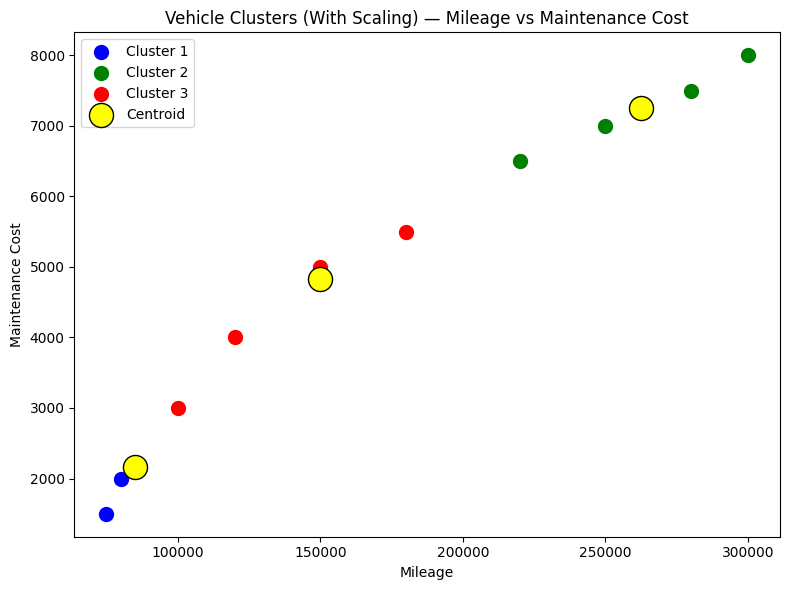

In [29]:
mtp.figure(figsize=(8, 6))
for i in range(3):
    mtp.scatter(
        x[y_scaled == i, 0],
        x[y_scaled == i, 2],
        s=100, c=colors[i], label=labels[i]
    )
mtp.scatter(
    kmeans_no_scale.cluster_centers_[:, 0],
    kmeans_no_scale.cluster_centers_[:, 2],
    s=300, c='yellow', label='Centroid', edgecolors='black'
)
mtp.title('Vehicle Clusters (With Scaling) — Mileage vs Maintenance Cost')
mtp.xlabel('Mileage')
mtp.ylabel('Maintenance Cost')
mtp.legend()
mtp.tight_layout()
mtp.show()

In [30]:
print("Cluster Assignment Comparison:")
print(df[['vehicle_serial_no', 'vehicle_type', 'mileage', 'fuel_efficiency',
          'maintenance_cost', 'cluster_no_scale', 'cluster_scaled']].to_string(index=False))

print("Cluster Sizes (No Scaling):")
print(pd.Series(y_no_scale).value_counts().sort_index())

print("Cluster Sizes (With Scaling):")
print(pd.Series(y_scaled).value_counts().sort_index())

print("Cluster Centers (No Scaling) — [mileage, fuel_efficiency, maintenance_cost, vehicle_type_encoded]:")
print(nm.round(kmeans_no_scale.cluster_centers_, 2))

print("Cluster Centers (With Scaling — scaled space):")
print(nm.round(kmeans_scaled.cluster_centers_, 2))


Cluster Assignment Comparison:
 vehicle_serial_no vehicle_type  mileage  fuel_efficiency  maintenance_cost  cluster_no_scale  cluster_scaled
                 5          SUV   150000               15              5000                 2               2
                 3        Sedan   120000               18              4000                 2               2
                 8        Truck   250000               10              7000                 1               1
                 2    Hatchback    80000               22              2000                 0               0
                 4        Sedan   100000               20              3000                 0               2
                 7        Truck   220000               12              6500                 1               1
                 6          SUV   180000               16              5500                 2               2
                10        Truck   300000                8              8000              